In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split

distill_df = pd.read_json(
    "../../out/distillation/medmcqa_deepseek_v3_filtered.jsonl",
    lines=True,
)

distill_df

,id,question,explanation,options,option_ids,answer,distill_ans_correct,distill_response,distill_answer
0,04563ab2-d5cd-4e0a-94a3-d680a274d151,Burn by moist heat is known as:,Burns may be classified as:\n\nOrdinary burns ...,"[Ordinary burn, Scar burn, Scalds burn, Hot burn]","[A, B, C, D]",C,True,"To determine the correct answer, let's analyze...",C
1,b24b5ebb-d46d-480f-b80c-67732327ee1b,HCN causes -,"Hydrocyanic acid Cyanide occurs as solid, liqu...",[Histotoxic anoxia by inhibiting carbonic anhy...,"[A, B, C, D]",C,True,"First, I need to recall what HCN is—hydrogen c...",C
2,10faac4c-857d-4945-913d-f3337d9409d8,Postponing paying attention of conscious impul...,Sublimation: Gratification of an impulse whose...,"[Sublimation, Suppression, Humor, Anticipation]","[A, B, C, D]",B,True,Let's analyze the question and the options:\n\...,B
3,09d127f1-e474-4d13-a58e-e137a3a7701d,An 8-year old boy presents with swelling in mi...,Ans. b. Ewing's sarcoma Ewing's sarcoma: A typ...,"[Osteosarcoma, Ewing's sarcoma, Tubercular ost...","[A, B, C, D]",B,True,Let's break this down step by step. \n\n1. **...,B
4,7ec3cd42-e42f-4d9e-ae3d-c0d3db10a0b3,"A 8 years old child with BP 180/100 mm Hg, Blo...",d. Chronic interstitial nephritis with VUR(Ref...,"[Post Infective glomerulonephritis, Accelerate...","[A, B, C, D]",D,True,Let’s break this down.\n\n1. **Age & presentat...,D
...,...,...,...,...,...,...,...,...,...
2467,02279a82-9afd-4792-b325-d9772d5d80eb,The El Tor biotype of vibrio cholerae was firs...,The El Tor biotype was first isolated at the E...,"[India, Egypt, Bangladesh, Pakistan]","[A, B, C, D]",B,True,The El Tor biotype of *Vibrio cholerae* was fi...,B
2468,1a57d3f1-0d1b-4097-892f-30fb6f3eb6c4,A 45-yr-old patient presents with a 4 x 5 cm m...,Head and neck squamous cell carcinoma of unkno...,"[T1N1M0, T1N2M0, T0N1M0, T0N2M0]","[A, B, C, D]",D,True,The patient has a neck mass that is a metastat...,D
2469,a8772ec9-416a-4a93-bde7-e70af899262d,Which of the following is not an embryologic s...,The face is derived from the following structu...,"[Frontonasal prominence, Zygomatic prominence,...","[A, B, C, D]",B,True,Let’s break this down:\n\nThe primary embryolo...,B
2470,fafb802d-fa37-4bca-8e23-ee8a87e87df4,Dorsiflexion of ankle joint is by,Muscles producing movements of ankle - A. Dors...,"[Tibialis anterior, Peroneus longus, Tibialis ...","[A, B, C, D]",A,True,Let’s break this down step by step. \n\n1. Do...,A


In [33]:
entropy_df = pd.read_json(
    "../../out/single_token_entropy/medmcqa_phi4mini.jsonl",
    lines=True,
)

entropy_df

,id,question,explanation,options,option_ids,answer,entropy_ans_correct,entropy_value,entropy_ans
0,04563ab2-d5cd-4e0a-94a3-d680a274d151,Burn by moist heat is known as:,Burns may be classified as:\n\nOrdinary burns ...,"[Ordinary burn, Scar burn, Scalds burn, Hot burn]","[A, B, C, D]",C,True,0.022948,C
1,b24b5ebb-d46d-480f-b80c-67732327ee1b,HCN causes -,"Hydrocyanic acid Cyanide occurs as solid, liqu...",[Histotoxic anoxia by inhibiting carbonic anhy...,"[A, B, C, D]",C,True,0.998528,C
2,10faac4c-857d-4945-913d-f3337d9409d8,Postponing paying attention of conscious impul...,Sublimation: Gratification of an impulse whose...,"[Sublimation, Suppression, Humor, Anticipation]","[A, B, C, D]",B,True,0.017996,B
3,09d127f1-e474-4d13-a58e-e137a3a7701d,An 8-year old boy presents with swelling in mi...,Ans. b. Ewing's sarcoma Ewing's sarcoma: A typ...,"[Osteosarcoma, Ewing's sarcoma, Tubercular ost...","[A, B, C, D]",B,True,0.744639,B
4,7ec3cd42-e42f-4d9e-ae3d-c0d3db10a0b3,"A 8 years old child with BP 180/100 mm Hg, Blo...",d. Chronic interstitial nephritis with VUR(Ref...,"[Post Infective glomerulonephritis, Accelerate...","[A, B, C, D]",D,False,0.584366,B
...,...,...,...,...,...,...,...,...,...
2995,3070adba-b575-41b8-8429-f19ceee62823,A patient with long-standing multinodular goit...,History of sudden growth in a long-standing go...,"[Follicular ca, Papillary ca, Medullary ca, An...","[A, B, C, D]",A,False,1.249898,D
2996,0d1b2245-1f59-40aa-b421-dacf5b68b90b,Endo metrial tuberculosis causing infertility ...,B. i.e. (Tubal blockage) (189 - Shaw's 14th) (...,"[Anovulation, Tubal blockage, Ciliary dysmotil...","[A, B, C, D]",B,True,0.075183,B
2997,4f139e3e-da32-46bd-94da-a928e71b9885,Earliest event in ischemic cardiac myocytes is:,Loss of contractility Features Time Onset of A...,"[Microvascular injury, Irreversible cell injur...","[A, B, C, D]",C,False,0.857152,A
2998,fafb802d-fa37-4bca-8e23-ee8a87e87df4,Dorsiflexion of ankle joint is by,Muscles producing movements of ankle - A. Dors...,"[Tibialis anterior, Peroneus longus, Tibialis ...","[A, B, C, D]",A,True,0.043196,A


In [34]:
distill_df = distill_df[['id', 'distill_response']]

In [35]:
df = distill_df.merge(entropy_df, on='id', suffixes=('_distill', '_entropy'), how='inner')

In [36]:
df.describe()

,entropy_value
count,2472.000000
mean,0.547550
std,0.441964
min,0.000170
25%,0.077710
50%,0.549313
75%,0.932191
max,1.619050


In [37]:
df

,id,distill_response,question,explanation,options,option_ids,answer,entropy_ans_correct,entropy_value,entropy_ans
0,04563ab2-d5cd-4e0a-94a3-d680a274d151,"To determine the correct answer, let's analyze...",Burn by moist heat is known as:,Burns may be classified as:\n\nOrdinary burns ...,"[Ordinary burn, Scar burn, Scalds burn, Hot burn]","[A, B, C, D]",C,True,0.022948,C
1,b24b5ebb-d46d-480f-b80c-67732327ee1b,"First, I need to recall what HCN is—hydrogen c...",HCN causes -,"Hydrocyanic acid Cyanide occurs as solid, liqu...",[Histotoxic anoxia by inhibiting carbonic anhy...,"[A, B, C, D]",C,True,0.998528,C
2,10faac4c-857d-4945-913d-f3337d9409d8,Let's analyze the question and the options:\n\...,Postponing paying attention of conscious impul...,Sublimation: Gratification of an impulse whose...,"[Sublimation, Suppression, Humor, Anticipation]","[A, B, C, D]",B,True,0.017996,B
3,09d127f1-e474-4d13-a58e-e137a3a7701d,Let's break this down step by step. \n\n1. **...,An 8-year old boy presents with swelling in mi...,Ans. b. Ewing's sarcoma Ewing's sarcoma: A typ...,"[Osteosarcoma, Ewing's sarcoma, Tubercular ost...","[A, B, C, D]",B,True,0.744639,B
4,7ec3cd42-e42f-4d9e-ae3d-c0d3db10a0b3,Let’s break this down.\n\n1. **Age & presentat...,"A 8 years old child with BP 180/100 mm Hg, Blo...",d. Chronic interstitial nephritis with VUR(Ref...,"[Post Infective glomerulonephritis, Accelerate...","[A, B, C, D]",D,False,0.584366,B
...,...,...,...,...,...,...,...,...,...,...
2467,02279a82-9afd-4792-b325-d9772d5d80eb,The El Tor biotype of *Vibrio cholerae* was fi...,The El Tor biotype of vibrio cholerae was firs...,The El Tor biotype was first isolated at the E...,"[India, Egypt, Bangladesh, Pakistan]","[A, B, C, D]",B,True,0.735828,B
2468,1a57d3f1-0d1b-4097-892f-30fb6f3eb6c4,The patient has a neck mass that is a metastat...,A 45-yr-old patient presents with a 4 x 5 cm m...,Head and neck squamous cell carcinoma of unkno...,"[T1N1M0, T1N2M0, T0N1M0, T0N2M0]","[A, B, C, D]",D,False,1.333603,B
2469,a8772ec9-416a-4a93-bde7-e70af899262d,Let’s break this down:\n\nThe primary embryolo...,Which of the following is not an embryologic s...,The face is derived from the following structu...,"[Frontonasal prominence, Zygomatic prominence,...","[A, B, C, D]",B,False,1.036321,D
2470,fafb802d-fa37-4bca-8e23-ee8a87e87df4,Let’s break this down step by step. \n\n1. Do...,Dorsiflexion of ankle joint is by,Muscles producing movements of ankle - A. Dors...,"[Tibialis anterior, Peroneus longus, Tibialis ...","[A, B, C, D]",A,True,0.043196,A


<Axes: >

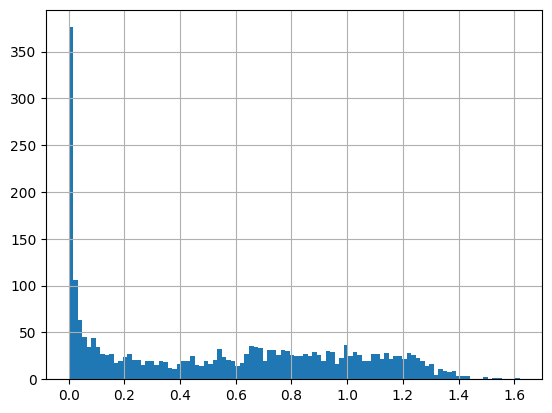

In [38]:
df["entropy_value"].hist(bins=100)

In [39]:
df["norm_entropy"] = df["entropy_value"] / df["entropy_value"].max()

In [40]:
df["norm_entropy"].describe().round(5)

count    2472.00000
mean        0.33819
std         0.27298
min         0.00010
25%         0.04800
50%         0.33928
75%         0.57576
max         1.00000
Name: norm_entropy, dtype: float64

In [41]:
len(df[(df["norm_entropy"] >= 0.57576)])

618

In [44]:
easy_df = df[(df["norm_entropy"] < 0.04800)]
middle_df = df[(df["norm_entropy"] >= 0.04800) & (df["norm_entropy"] < 0.57576)]
hard_df = df[(df["norm_entropy"] >= 0.57576)]

In [45]:
train_combined_df = pd.concat([easy_df, middle_df, hard_df], ignore_index=True)
train_combined_df

,id,distill_response,question,explanation,options,option_ids,answer,entropy_ans_correct,entropy_value,entropy_ans,norm_entropy
0,04563ab2-d5cd-4e0a-94a3-d680a274d151,"To determine the correct answer, let's analyze...",Burn by moist heat is known as:,Burns may be classified as:\n\nOrdinary burns ...,"[Ordinary burn, Scar burn, Scalds burn, Hot burn]","[A, B, C, D]",C,True,0.022948,C,0.014174
1,10faac4c-857d-4945-913d-f3337d9409d8,Let's analyze the question and the options:\n\...,Postponing paying attention of conscious impul...,Sublimation: Gratification of an impulse whose...,"[Sublimation, Suppression, Humor, Anticipation]","[A, B, C, D]",B,True,0.017996,B,0.011115
2,816e6b03-54fb-494f-9dec-03a383ca6fdf,"First, recall that Meckel's diverticulum is a ...",Meckel's diveiculum is a remnant of:,D i.e. Vitellointestinal duct- Persistence of ...,"[Stenson's duct, Wolffian duct, Mullerian duct...","[A, B, C, D]",D,True,0.004423,D,0.002732
3,2cb62211-c6b7-4b90-ac2c-525a33dcda96,Let’s go step by step. \n\n1. The question sa...,The most common congenital cardiac lesion iden...,Ventricular Septal Defect (VSD) This is the mo...,"[ASD, VSD, PDA, Coarctation of Aoa]","[A, B, C, D]",B,True,0.047960,B,0.029622
4,080352ad-7e86-4226-b64e-f49556d40ecc,The patient is a 24-year-old man on chronic co...,A 24-year-old man on chronic corticosteroid th...,"Risk factors for osteoporosis include smoking,...","[Gaucher disease, Osteomalacia, Osteopetrosis,...","[A, B, C, D]",D,True,0.007140,D,0.004410
...,...,...,...,...,...,...,...,...,...,...,...
2467,f23fbebd-c4ef-4961-9c9d-9295e10533e9,To determine which disease does not have carri...,Carriers not seen in ?,"Ans. is 'a' i.e., Rabies","[Rabies, Typhoid fever, Polio, Malaria]","[A, B, C, D]",A,True,1.314027,A,0.811603
2468,401377e9-c05e-4315-bc20-40b6343f2942,"In blunt abdominal trauma, the exact injured o...",Which is the preferred incision for abdominal ...,The preferred incision for emergency abdominal...,"[Transverse incision, Paramedian incision, Alw...","[A, B, C, D]",C,False,1.056165,B,0.652336
2469,fd3bc633-2fb4-4e6d-9696-3db40d83b947,Let’s break this down: \n\n1. **Location of w...,A man was found with suicidal gunshot on right...,Ans. Contact shot,"[Contact shot, Close shot at a distance of 1 f...","[A, B, C, D]",A,False,1.029213,C,0.635689
2470,1a57d3f1-0d1b-4097-892f-30fb6f3eb6c4,The patient has a neck mass that is a metastat...,A 45-yr-old patient presents with a 4 x 5 cm m...,Head and neck squamous cell carcinoma of unkno...,"[T1N1M0, T1N2M0, T0N1M0, T0N2M0]","[A, B, C, D]",D,False,1.333603,B,0.823695


In [46]:
train_random_df = train_combined_df.sample(618, random_state=42)

In [47]:
easy_df.to_json("../entropy/phi/medmcqa_train_easy.jsonl", lines=True, orient="records")
middle_df.to_json("../entropy/phi/medmcqa_train_middle.jsonl", lines=True, orient="records")
hard_df.to_json("../entropy/phi/medmcqa_train_hard.jsonl", lines=True, orient="records")
train_combined_df.to_json("../entropy/phi/medmcqa_train_combined.jsonl", lines=True, orient="records")
train_random_df.to_json("../entropy/phi/medmcqa_train_random.jsonl", lines=True, orient="records")